In [31]:
import wrds
import datetime
import numpy as np
import pandas as pd
from itertools import chain
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:



# Matteo's original actions and stakeholders
def dict_2d_actions_stakeholders_original_matteo(signal_0_name="advocacy", signal_1_name="preparation", signal_2_name="transformation"):
    
    return{
        # 'TYPE: association': 0, 
        # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
        'TYPE: donation & funding': 0, 
        'TYPE: volunteerism': 0, 
        'TYPE_SREC: communication - local communities and society': 0, 
        'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
        'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
        'TYPE_SREC: organizational structuring - local communities and society': 0, 

        'TYPE: adoption of standards and rules': 1, 
        'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
        'TYPE_SREC: communication - employees': 1, 
        'TYPE_SREC: training - employees': 1, 
        'TYPE_SREC: incentives - employees': 1, 
        'TYPE_SREC: organizational structuring - employees': 1, 

        'TYPE: asset modification': 2,
        'TYPE: modification of procedures': 2, 
        'TYPE: new products': 2, 
        'TYPE: r&d investments': 2, 
        'TYPE_SREC: communication - customers': 2, 
        'TYPE_SREC: communication - shareholders': 2, 
        'TYPE_SREC: communication - suppliers': 2, 
        'TYPE_SREC: training - customers': 2, 
        'TYPE_SREC: training - shareholders': 2, 
        'TYPE_SREC: training - suppliers': 2, 
        'TYPE_SREC: incentives - customers': 2, 
        'TYPE_SREC: incentives - shareholders': 2, 
        'TYPE_SREC: incentives - suppliers': 2, 
        'TYPE_SREC: organizational structuring - customers': 2, 
        'TYPE_SREC: organizational structuring - shareholders': 2, 
        'TYPE_SREC: organizational structuring - suppliers': 2, 
    }, signal_0_name, signal_1_name, signal_2_name

categories_dict, signal_0_name, signal_1_name, signal_2_name = dict_2d_actions_stakeholders_original_matteo()

In [33]:
def map_sectors(x):
    # Skip Industrials, Health Care, Utilities
    if x in ['Energy', 'Materials']:
        return 'Primary Industries'
    elif x in ['Consumer Discretionary', 'Consumer Staples']:
        return 'Consumer'

    # make Financial = Financials if you want to include finance sector
    elif x in ['Financials', 'Real Estate']:
        return 'Financial'
    elif x in ['Communication Services', 'Information Technology']:
        return 'ICT'
    return x

### 4. EDA

In [ ]:
#Golden Dataset Location
from pathlib import Path
import os

golden_location = Path(
    os.environ.get(
        "GOLDEN_LOCATION",
        Path.home() / "Documents" / "GitHub" / "data" / "Golden_Data",
    )
)

lc = pd.read_csv(golden_location / "LC_dataset_v_2A.csv")
lc = pd.read_csv(golden_location / "LC_dataset_v_2B1_20260409.csv")



start_year = 2013
end_year = 2024
lc = lc[lc['rfyear'] >= start_year]
lc = lc[lc['rfyear'] <= end_year]

region = "Japan"
if region == 'Japan':
    lc = lc[lc['loc'] == 'JPN']


lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)

lc = lc.dropna(subset=["Industry"])


C:\Users\chris\AppData\Local\Temp\ipykernel_18052\1336318930.py:5: DtypeWarning: Columns (514) have mixed types. Specify dtype option on import or set low_memory=False.
  lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')


In [35]:
for (key, value) in categories_dict.items():
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Sum Activites Stats

In [36]:

# multiple stats per year
lc.groupby("rfyear")["sum_activities"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,43.386707,46.749769,2.0,14.00,28.0,54.50,322.0
2014,374.0,46.804813,51.876187,1.0,14.00,30.0,60.50,388.0
2015,380.0,44.102632,47.268307,2.0,14.00,28.5,55.25,281.0
2016,430.0,38.027907,44.679737,1.0,11.00,23.0,47.00,271.0
2017,448.0,35.051339,40.979446,1.0,10.00,20.0,42.00,246.0
2018,488.0,29.424180,34.332987,1.0,10.00,18.0,34.00,270.0
2019,541.0,27.805915,34.230121,1.0,10.00,17.0,31.00,373.0
2020,617.0,29.090762,37.379871,0.0,9.00,18.0,32.00,418.0
2021,724.0,29.828729,40.018992,1.0,8.75,17.0,32.00,465.0


Advocacy Stats

In [37]:
lc.groupby("rfyear")["signal_0"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.447495,0.215953,0.0,0.312500,0.434783,0.562178,1.0
2014,374.0,0.419314,0.216948,0.0,0.285714,0.398276,0.532813,1.0
2015,380.0,0.396016,0.217509,0.0,0.250000,0.375000,0.510023,1.0
2016,430.0,0.427140,0.224410,0.0,0.266667,0.400000,0.571429,1.0
2017,448.0,0.417515,0.221453,0.0,0.259868,0.400000,0.555556,1.0
2018,488.0,0.408599,0.227229,0.0,0.261885,0.394103,0.545455,1.0
2019,541.0,0.383749,0.225595,0.0,0.230769,0.375000,0.500000,1.0
2020,616.0,0.386938,0.232745,0.0,0.250000,0.363636,0.502660,1.0
2021,724.0,0.357491,0.227829,0.0,0.200000,0.333333,0.500000,1.0


Preparation Stats

In [38]:
lc.groupby("rfyear")["signal_1"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.248461,0.160167,0.0,0.144599,0.238095,0.355958,0.750
2014,374.0,0.257233,0.162328,0.0,0.142857,0.250000,0.355783,1.000
2015,380.0,0.279942,0.176295,0.0,0.161290,0.282718,0.380952,1.000
2016,430.0,0.258024,0.165308,0.0,0.134483,0.260870,0.362891,1.000
2017,448.0,0.276352,0.172569,0.0,0.161622,0.266667,0.384615,1.000
2018,488.0,0.278798,0.178004,0.0,0.157484,0.267949,0.400000,1.000
2019,541.0,0.261769,0.179004,0.0,0.136364,0.250000,0.380952,0.875
2020,616.0,0.264400,0.183825,0.0,0.141626,0.250000,0.371595,1.000
2021,724.0,0.257570,0.175140,0.0,0.142857,0.250000,0.368466,1.000


Transformation Stats

In [39]:
lc.groupby("rfyear")["signal_2"].describe()

,count,mean,std,min,25%,50%,75%,max
rfyear,,,,,,,,
2013,331.0,0.304044,0.166676,0.0,0.200000,0.300000,0.388889,1.0
2014,374.0,0.323453,0.181325,0.0,0.209890,0.318813,0.409091,1.0
2015,380.0,0.324042,0.168185,0.0,0.206760,0.315789,0.425325,1.0
2016,430.0,0.314836,0.182587,0.0,0.200000,0.285714,0.409091,1.0
2017,448.0,0.306132,0.180022,0.0,0.200000,0.282957,0.404923,1.0
2018,488.0,0.312603,0.188156,0.0,0.199242,0.300000,0.411765,1.0
2019,541.0,0.354481,0.218647,0.0,0.208333,0.333333,0.460177,1.0
2020,616.0,0.348662,0.200516,0.0,0.222222,0.333333,0.450000,1.0
2021,724.0,0.384939,0.208206,0.0,0.250000,0.363636,0.500000,1.0


In [40]:
lc.loc[lc['loc'] == 'JPN', 'gvkey'].unique().shape

(1274,)

In [41]:
# MANUAL INPUT

#change below to the above sdg - evn and non env>
plt_title_suffix = 'Innovation'
plt_max_to_min_title_suffix = 'Innovation to advocacy'

# FIND MIN AND MAX CATEGORY ID
min_category = min(categories_dict.values())
max_category = max(categories_dict.values())



##### GICS

In [42]:
# Define a CVD-friendly colour map and line styles
colours = plt.cm.viridis(np.linspace(0, 1, len(lc['Industry'].unique())))
line_styles = ['-', '--', '-.', ':']
markers = ['o', 's', 'D', '^', 'x', '*']

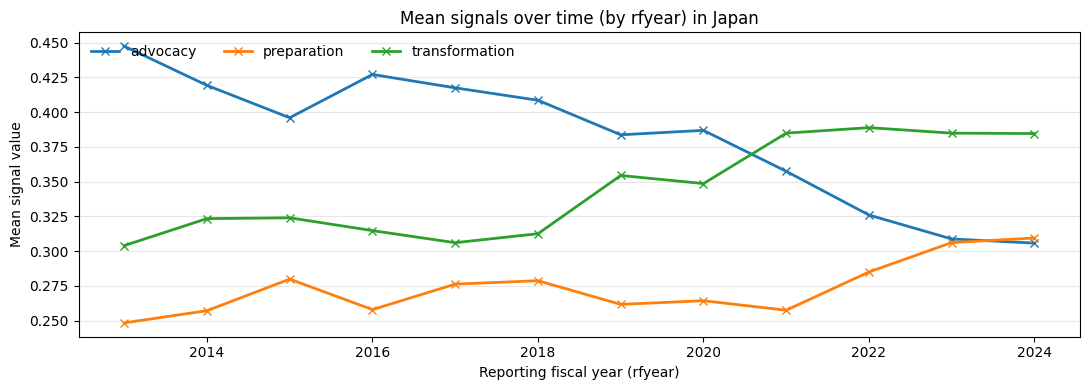

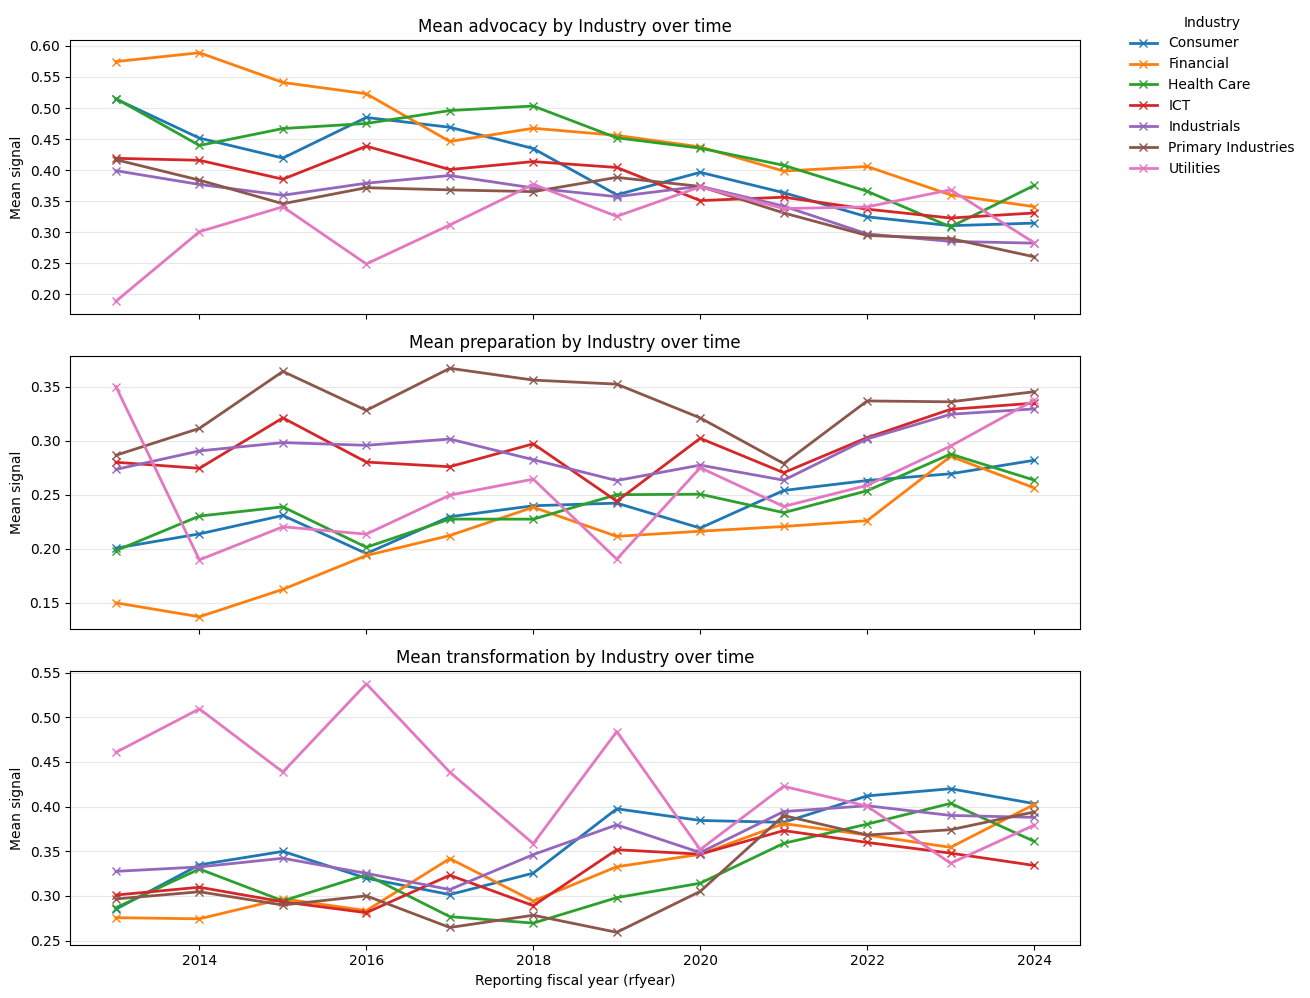

In [43]:
# --------------------------------------------------------------
# Mean signals over time
# - (1) Mean signal_0/1/2 by rfyear
# - (2) Mean signal by rfyear × Industry over time
# --------------------------------------------------------------

from functions.eda_signal_plots import (
    ensure_signal_columns,
    plot_mean_signals_by_rfyear,
    plot_mean_signals_by_rfyear_industry,
)

# Ensure we have signal_0/1/2 columns (fallback: sum_with_0/1/2 divided by sum_activities)
lc_plot, sig_cols = ensure_signal_columns(lc)

signal_cols = sig_cols.as_list
signal_labels = [signal_0_name, signal_1_name, signal_2_name]

# (1) Mean of each signal by fiscal year
_ = plot_mean_signals_by_rfyear(
    lc_plot,
    rfyear_col="rfyear",
    signal_cols=signal_cols,
    signal_labels=signal_labels,
    marker="x",
    title=f"Mean signals over time (by rfyear) in {region}",
)

# (2) Mean signals by fiscal year and Industry over time
_ = plot_mean_signals_by_rfyear_industry(
    lc_plot,
    rfyear_col="rfyear",
    industry_col="Industry",
    signal_cols=signal_cols,
    signal_labels=signal_labels,
    plot_top_n=10,
    marker="x",
)

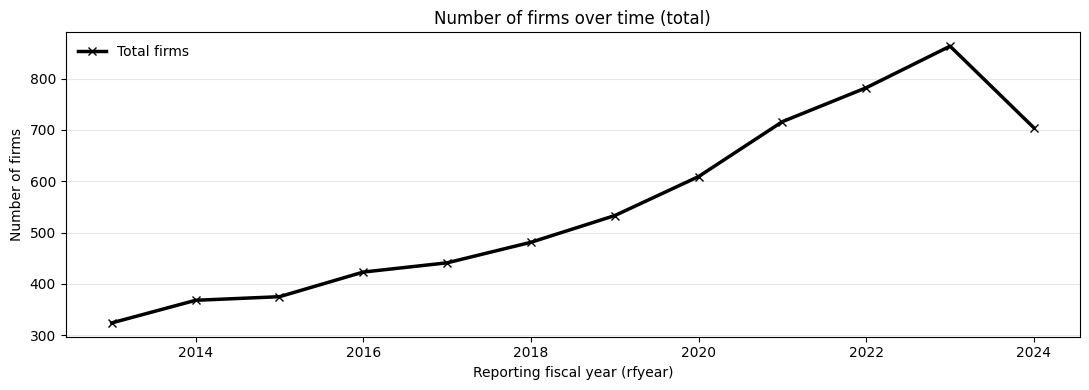

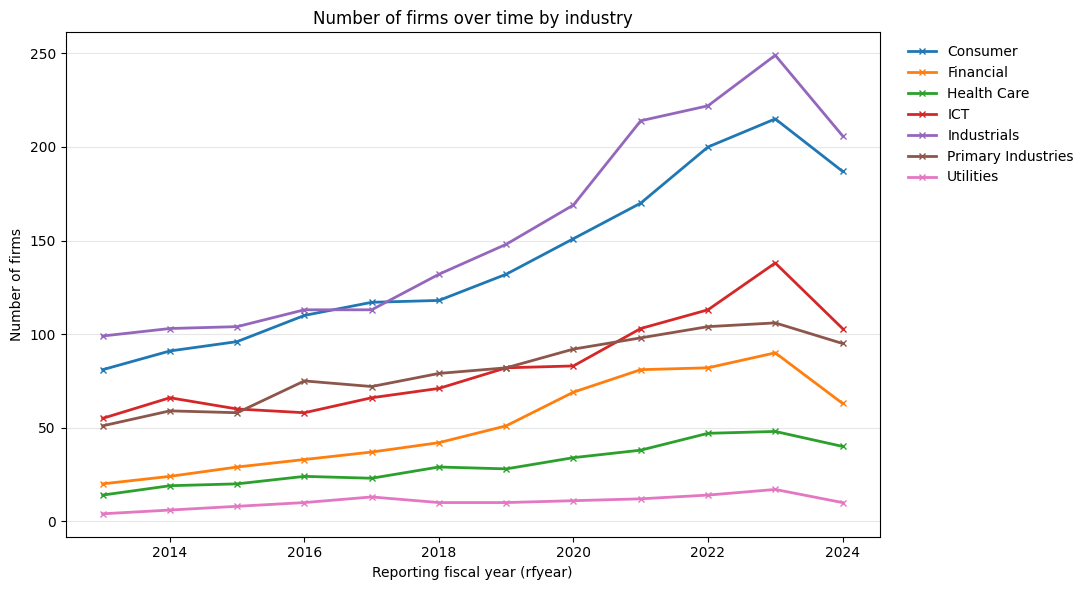

In [45]:
# Total number of firms over time (split by industry)
plot_top_n = 10  # keep plot readable; set to None to show all industries

# `lc` is the main long-format dataset used throughout this notebook.
tmp = lc[['gvkey', 'rfyear', 'Industry']].dropna(subset=['gvkey', 'rfyear']).copy()
tmp['Industry'] = tmp['Industry'].fillna('Unknown').astype(str)

firm_counts = tmp.groupby(['rfyear', 'Industry'])['gvkey'].nunique().reset_index(name='n_firms')
total_counts = tmp.groupby('rfyear')['gvkey'].nunique().sort_index()

pivot = (
    firm_counts
    .pivot(index='rfyear', columns='Industry', values='n_firms')
    .fillna(0)
    .sort_index()
)

industry_sums = pivot.sum(axis=0).sort_values(ascending=False)
if plot_top_n is not None and pivot.shape[1] > plot_top_n:
    top_industries = industry_sums.head(plot_top_n).index
    other_industries = industry_sums.index.difference(top_industries)
    pivot_plot = pivot[top_industries].copy()
    if len(other_industries) > 0:
        pivot_plot['Other'] = pivot[other_industries].sum(axis=1)
else:
    pivot_plot = pivot

# -----------------------------------------------------------------
# Plot 1: total firms over time
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    total_counts.index,
    total_counts.values,
    color='black',
    linewidth=2.5,
    label='Total firms',
    marker='x',
    markersize=6,
)
ax.set_title('Number of firms over time (total)')
ax.set_xlabel('Reporting fiscal year (rfyear)')
ax.set_ylabel('Number of firms')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------
# Plot 2: firms over time split by industry
# -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))
for col in pivot_plot.columns:
    ax.plot(
        pivot_plot.index,
        pivot_plot[col].values,
        linewidth=2,
        label=str(col),
        marker='x',
        markersize=4,
    )
ax.set_title('Number of firms over time by industry')
ax.set_xlabel('Reporting fiscal year (rfyear)')
ax.set_ylabel('Number of firms')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=False)
plt.tight_layout()
plt.show()
